# AdaBoost from Scratch

A simple implementation of AdaBoost for binary classification using decision stumps.

Labels are represented as `-1` and `+1`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Create a small dataset

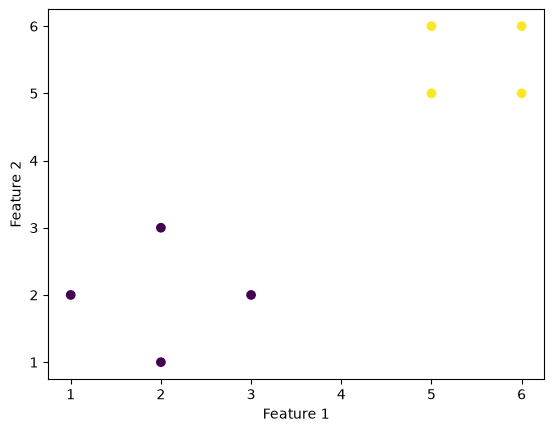

In [2]:
X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2],
    [5, 5],
    [6, 5],
    [5, 6],
    [6, 6]
], dtype=float)

y = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Weak learner: Decision Stump

The stump chooses one feature and one threshold.

In [3]:
class DecisionStump:
    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.polarity = 1

    def fit(self, X, y, weights):
        n_samples, n_features = X.shape
        best_error = float('inf')

        for feature in range(n_features):
            values = X[:, feature]

            for threshold in np.unique(values):
                for polarity in [1, -1]:
                    predictions = np.ones(n_samples)

                    if polarity == 1:
                        predictions[values < threshold] = -1
                    else:
                        predictions[values >= threshold] = -1

                    error = np.sum(weights[predictions != y])

                    if error < best_error:
                        best_error = error
                        self.feature_index = feature
                        self.threshold = threshold
                        self.polarity = polarity

        return best_error

    def predict(self, X):
        values = X[:, self.feature_index]
        predictions = np.ones(X.shape[0])

        if self.polarity == 1:
            predictions[values < self.threshold] = -1
        else:
            predictions[values >= self.threshold] = -1

        return predictions

## AdaBoost classifier

In [4]:
class AdaBoost:
    def __init__(self, n_estimators=5):
        self.n_estimators = n_estimators
        self.models = []
        self.alphas = []

    def fit(self, X, y):
        n_samples = len(y)

        # Step 1: equal weights
        weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            # Step 2: train weak learner
            stump = DecisionStump()
            error = stump.fit(X, y, weights)

            # Step 3: predictions
            predictions = stump.predict(X)

            # Step 5: weak learner importance
            error = np.clip(error, 1e-10, 1 - 1e-10)
            alpha = 0.5 * np.log((1 - error) / error)

            # Step 6: update sample weights
            weights *= np.exp(-alpha * y * predictions)

            # Step 7: normalize weights
            weights /= np.sum(weights)

            self.models.append(stump)
            self.alphas.append(alpha)

    def predict(self, X):
        final_score = np.zeros(X.shape[0])

        for alpha, model in zip(self.alphas, self.models):
            final_score += alpha * model.predict(X)

        return np.sign(final_score)

## Train the model

In [5]:
model = AdaBoost(n_estimators=5)
model.fit(X, y)

## Predictions

In [6]:
predictions = model.predict(X)

print('True labels: ', y)
print('Predictions: ', predictions)

True labels:  [-1 -1 -1 -1  1  1  1  1]
Predictions:  [-1. -1. -1. -1.  1.  1.  1.  1.]


## Accuracy

In [7]:
accuracy = np.mean(predictions == y)
print('Accuracy:', accuracy)

Accuracy: 1.0


## Inspect the weak learners

In [8]:
for i, (model, alpha) in enumerate(zip(model.models, model.alphas)):
    print(f'Learner {i + 1}')
    print('  feature:', model.feature_index)
    print('  threshold:', model.threshold)
    print('  alpha:', round(alpha, 3))

Learner 1
  feature: 0
  threshold: 5.0
  alpha: 11.513
Learner 2
  feature: 0
  threshold: 5.0
  alpha: 11.513
Learner 3
  feature: 0
  threshold: 5.0
  alpha: 11.513
Learner 4
  feature: 0
  threshold: 5.0
  alpha: 11.513
Learner 5
  feature: 0
  threshold: 5.0
  alpha: 11.513
